In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [30]:
dataset_path = Path('data/nodes/6nodes_serverset.csv')
df = pd.read_csv(dataset_path,  dtype={'run_id': str})
plt.style.use('acm.mplstyle')

In [31]:
mask72 = (
    (df['tdd'] == '7-2') &
    (df['distribution'] == 'dirichlet') &
    (df['rank']== '2x2') &
    (df['network'] == 'wwan') &
    (df['nodes'] == '6N')
)
df72 = df[mask72].copy()

In [32]:
data_size = 2.9172 * 8

In [33]:
mu = 1
T_s = 1e-3 / (14 *2 ** mu)
R_max = 948 / 1024
f = 1
OH_dl = 0.14
OH_ul = 0.08
v_layers = 2

def calc_ratios(dl_slots, ul_slots, period_slots):
    flex_slots = period_slots - dl_slots - ul_slots
    # Flexible slot: 6/14 DL, 4/14 UL symbols
    eff_dl = (dl_slots + flex_slots * 6 / 14) / period_slots
    eff_ul = (ul_slots + flex_slots * 4 / 14) / period_slots
    return {'dl': eff_dl, 'ul': eff_ul}

# mu=1 -> 0.5ms slots -> 5ms = 10 slots, 2.5ms = 5 slots
slot_configs = {
    '7:2': calc_ratios(7, 2, 10),   # 1 flex slot
    '5:4': calc_ratios(5, 4, 10),   # 1 flex slot
    '2:7': calc_ratios(2, 7, 10),   # 1 flex slot
    '3:1': calc_ratios(3, 1, 5),    # 1 flex slot
    '2:2': calc_ratios(2, 2, 5),    # 1 flex slot
}

N_PRB = {'20 MHz': 51, '40 MHz': 106, '60 MHz': 162,'80 MHz': 217, '100 MHz': 273}

def theoretical_throughput(bw, Qm, slot_config='7:2', direction='dl'):
    oh = OH_dl if direction == 'dl' else OH_ul
    allocated_slots = slot_configs[slot_config][direction]
    return 1e-6 * v_layers * Qm * f * R_max * ((N_PRB[bw] * 12) / T_s) * (1 - oh) * allocated_slots
bandwidths = ['20 MHz', '40 MHz', '80 MHz', '100 MHz']

Scaling Factor: 37.903988836030365
Scaling Factor: 37.903988836030365
Scaling Factor: 37.903988836030365
Scaling Factor: 37.903988836030365
Scaling Factor: 37.903988836030365


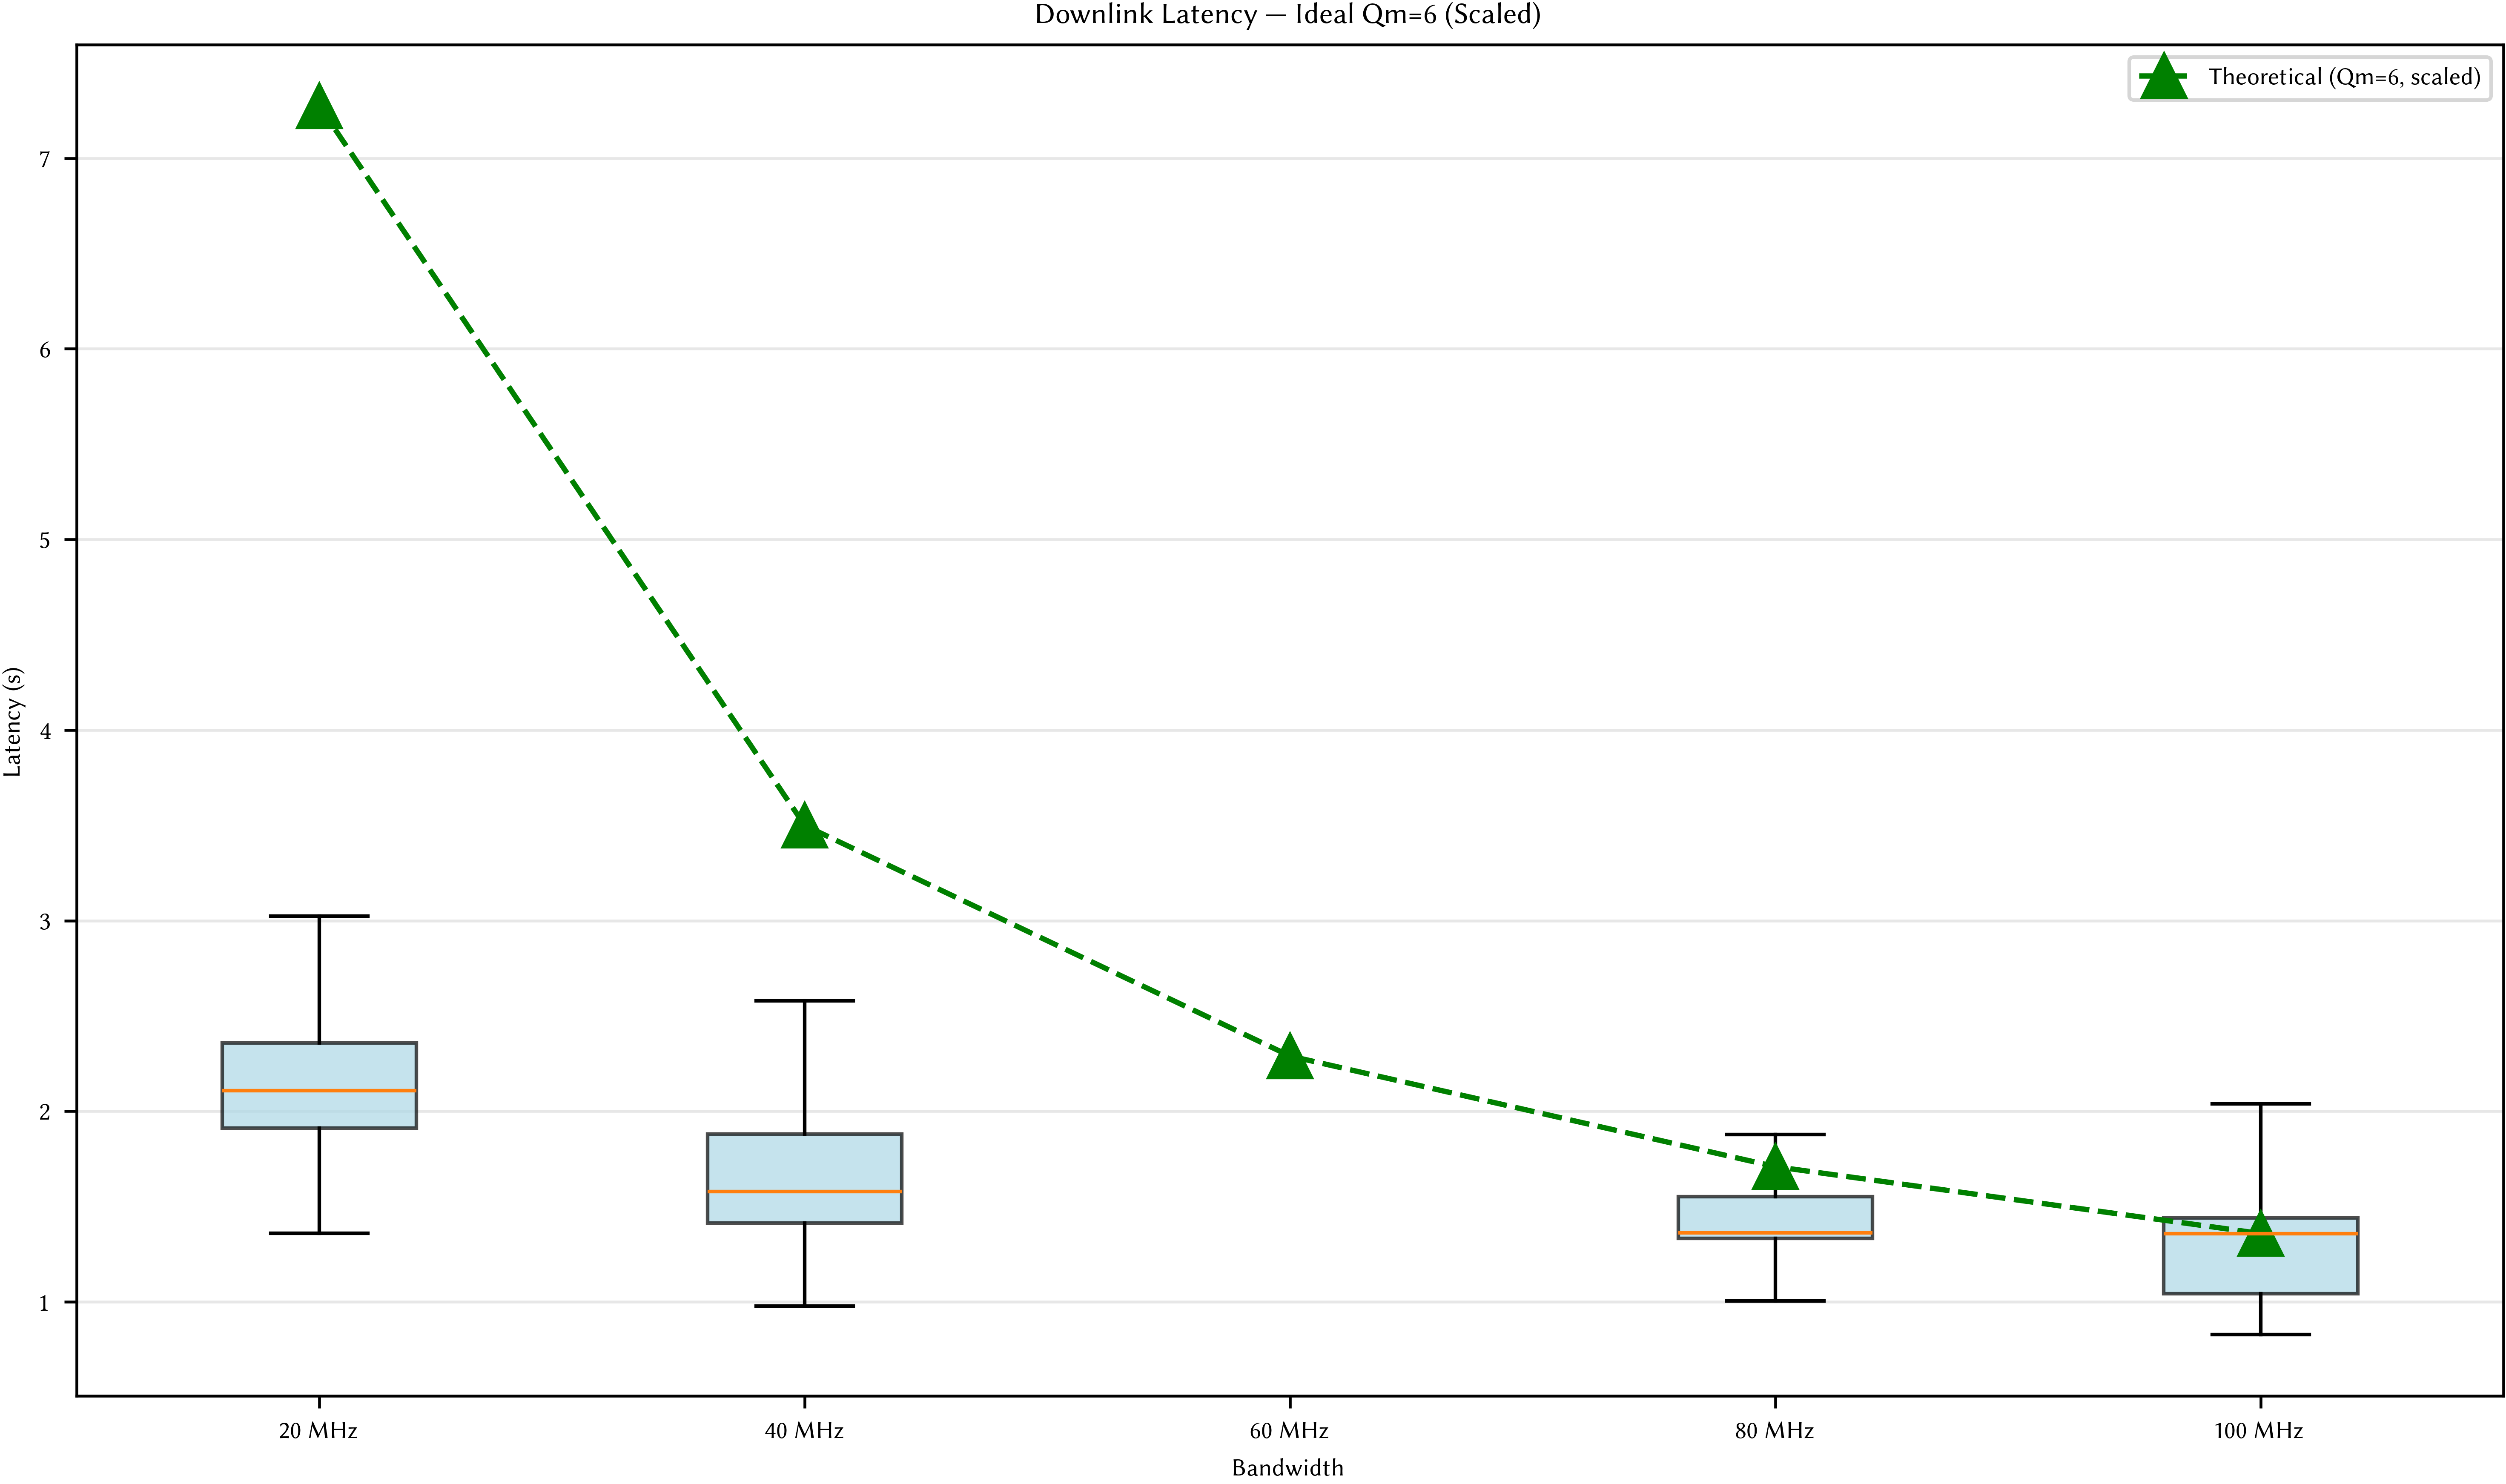

Scaling Factor: 16.43817801865665
Scaling Factor: 16.43817801865665
Scaling Factor: 16.43817801865665
Scaling Factor: 16.43817801865665
Scaling Factor: 16.43817801865665


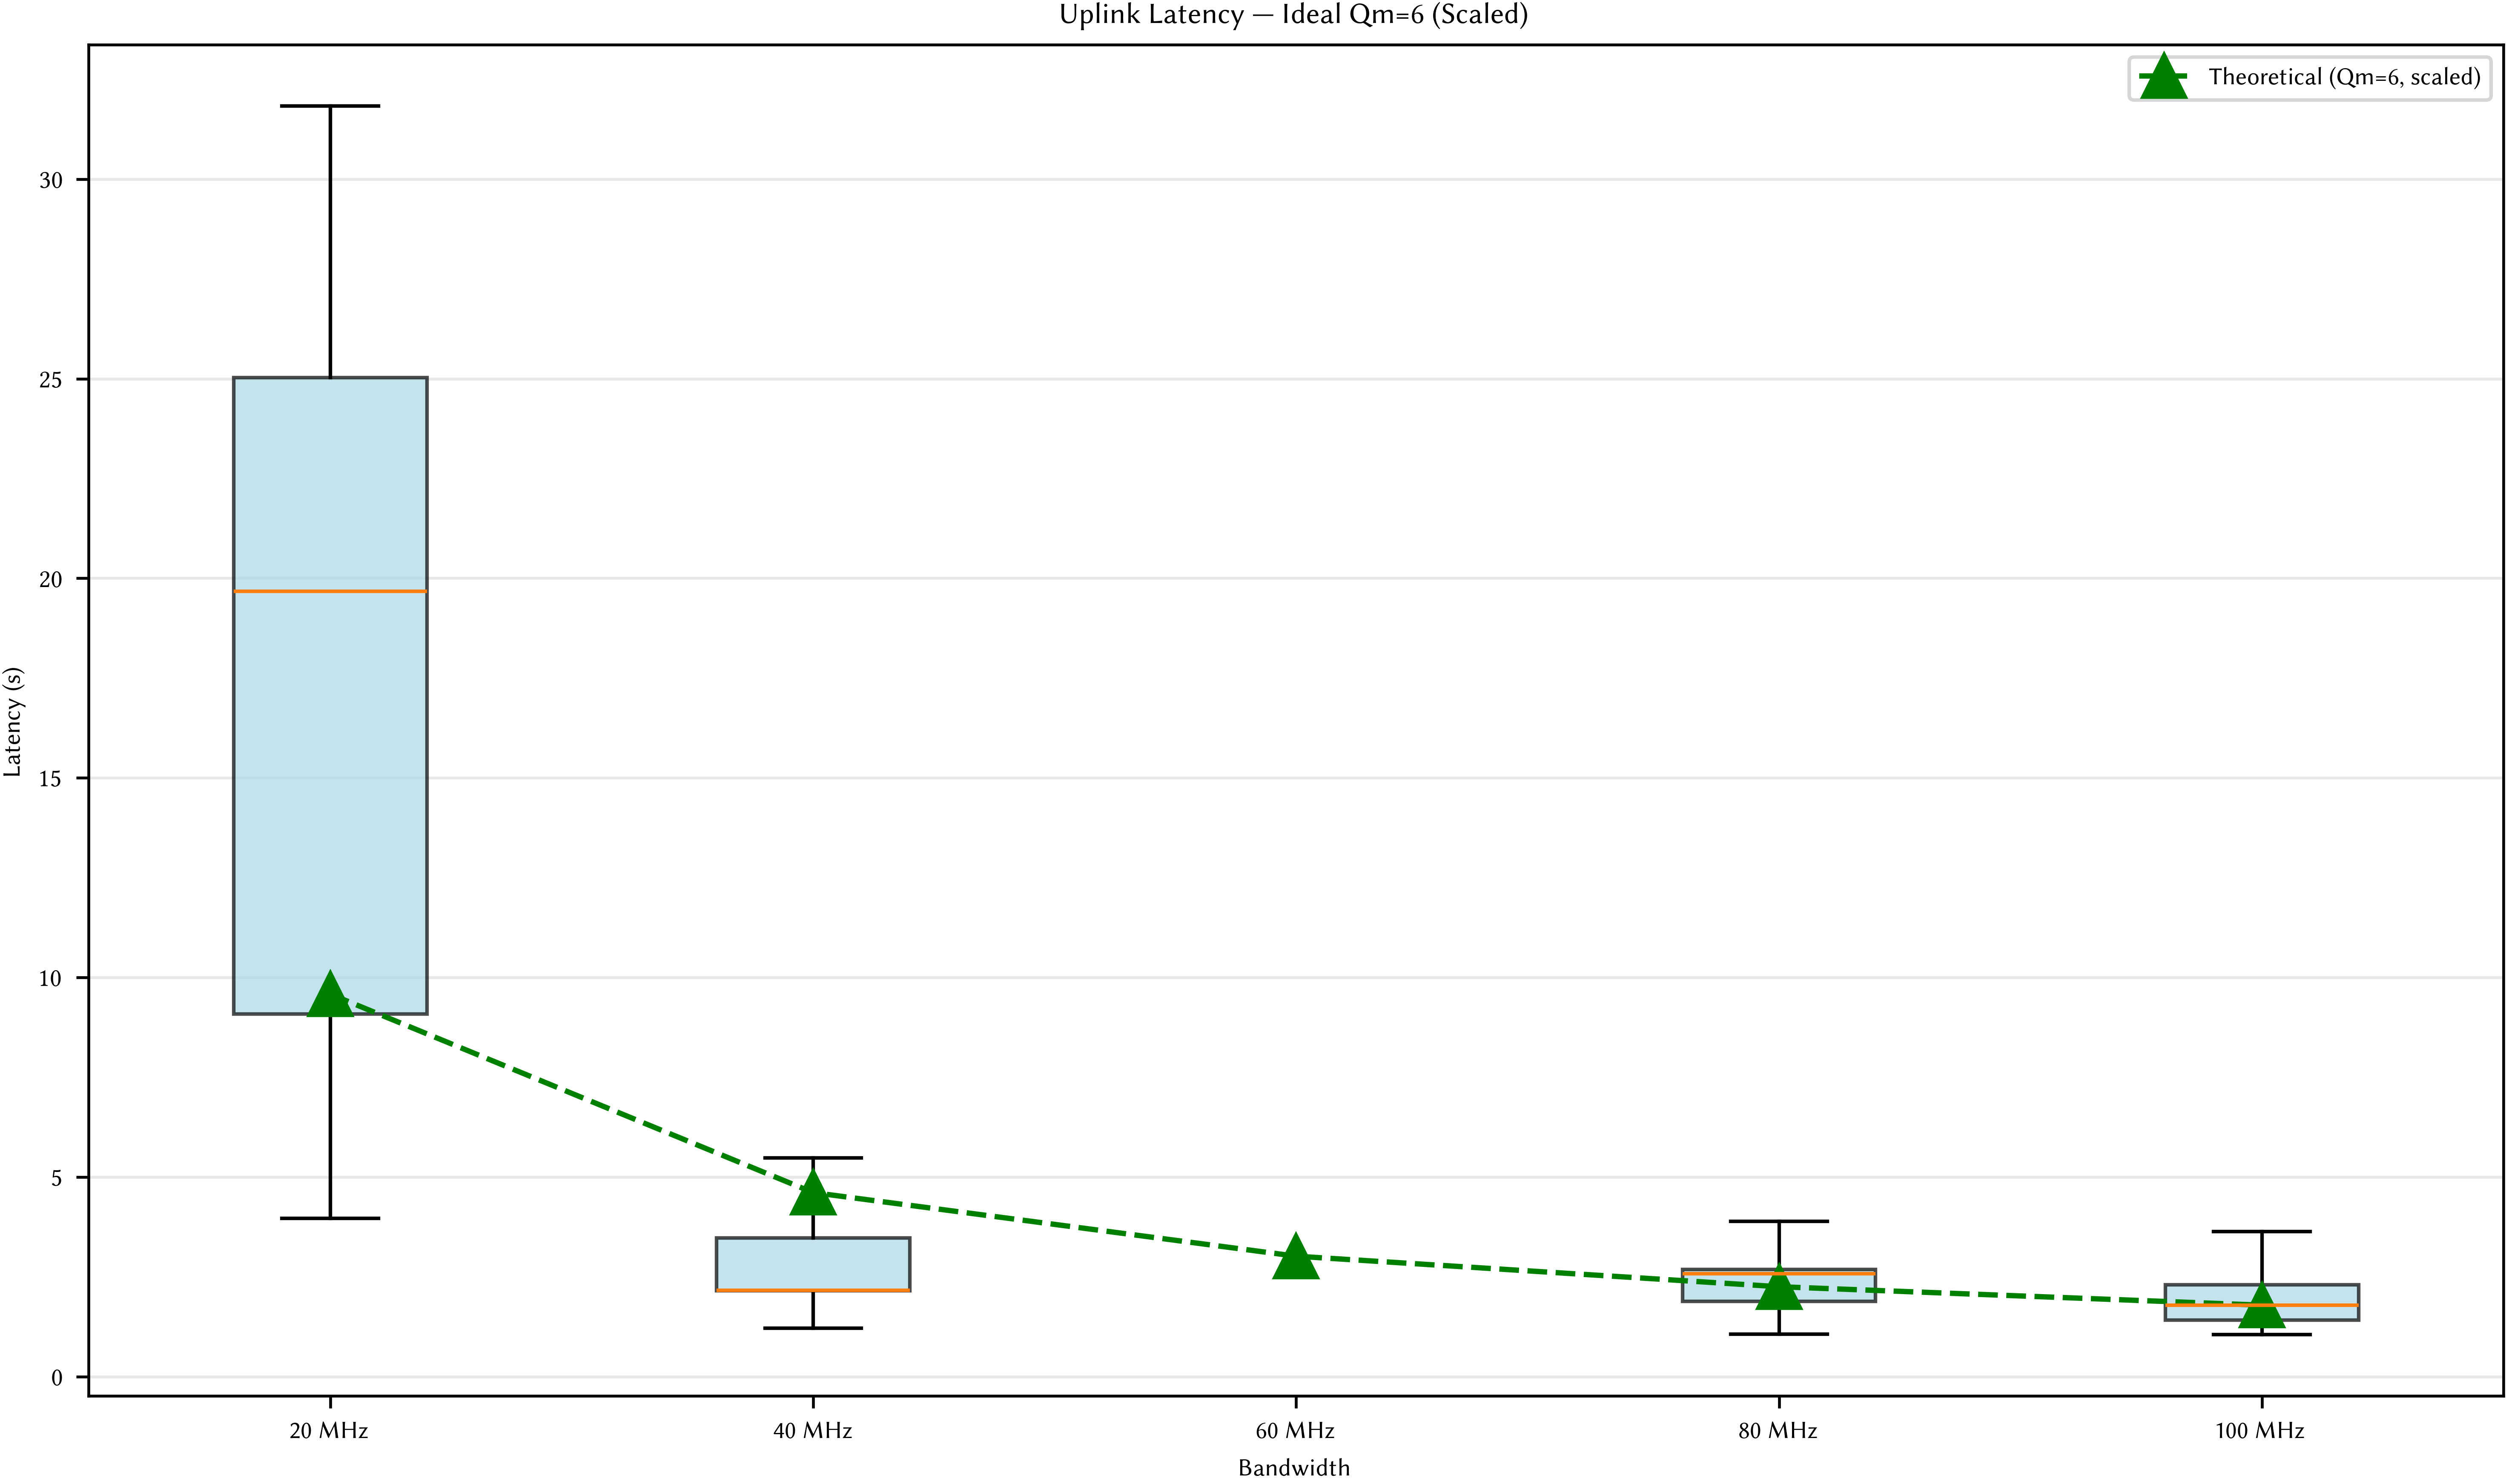

In [37]:
# --- Ideal Qm=6, scaled to experiment — Latency — Separate figures ---
bandwidths_with_60 = ['20 MHz', '40 MHz', '60 MHz', '80 MHz', '100 MHz']
N_PRB['60 MHz'] = 162
data_size = 2.9172 * 8  # megabits

for direction, tput_col, label in zip(
    ['dl', 'ul'], ['downlink_latency', 'uplink_latency'],
    ['Downlink', 'Uplink']
):
    fig, ax = plt.subplots(figsize=(10, 6))

    s100 = df[df['bandwidth'] == '100 MHz']
    theo_100 = data_size / theoretical_throughput('100 MHz', 6, '7:2', direction)
    measured_100 = s100[tput_col].median()
    scale = measured_100 / theo_100

    box_data = []
    box_positions = []
    tick_labels = []
    theo_vals = []
    theo_positions = []

    pos = 0
    for bw in bandwidths_with_60:
        subset = df[df['bandwidth'] == bw]
        if not subset.empty:
            box_data.append(subset[tput_col].dropna().values)
            box_positions.append(pos)
        theo_vals.append(data_size / theoretical_throughput(bw, 6, '7:2', direction) * scale)
        print(f'Scaling Factor: {scale}')
        theo_positions.append(pos)
        tick_labels.append(bw)
        pos += 1

    ax.boxplot(box_data, positions=box_positions, widths=0.4, patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7), showfliers=False)
    ax.plot(theo_positions, theo_vals, 'g^--', markersize=12, label='Theoretical (Qm=6, scaled)')

    ax.set_xticks(theo_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel('Bandwidth')
    ax.set_ylabel('Latency (s)')
    ax.set_title(f'{label} Latency — Ideal Qm=6 (Scaled)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'latency_ideal_qm_scaled_{direction}.pdf', dpi=150)
    plt.show()

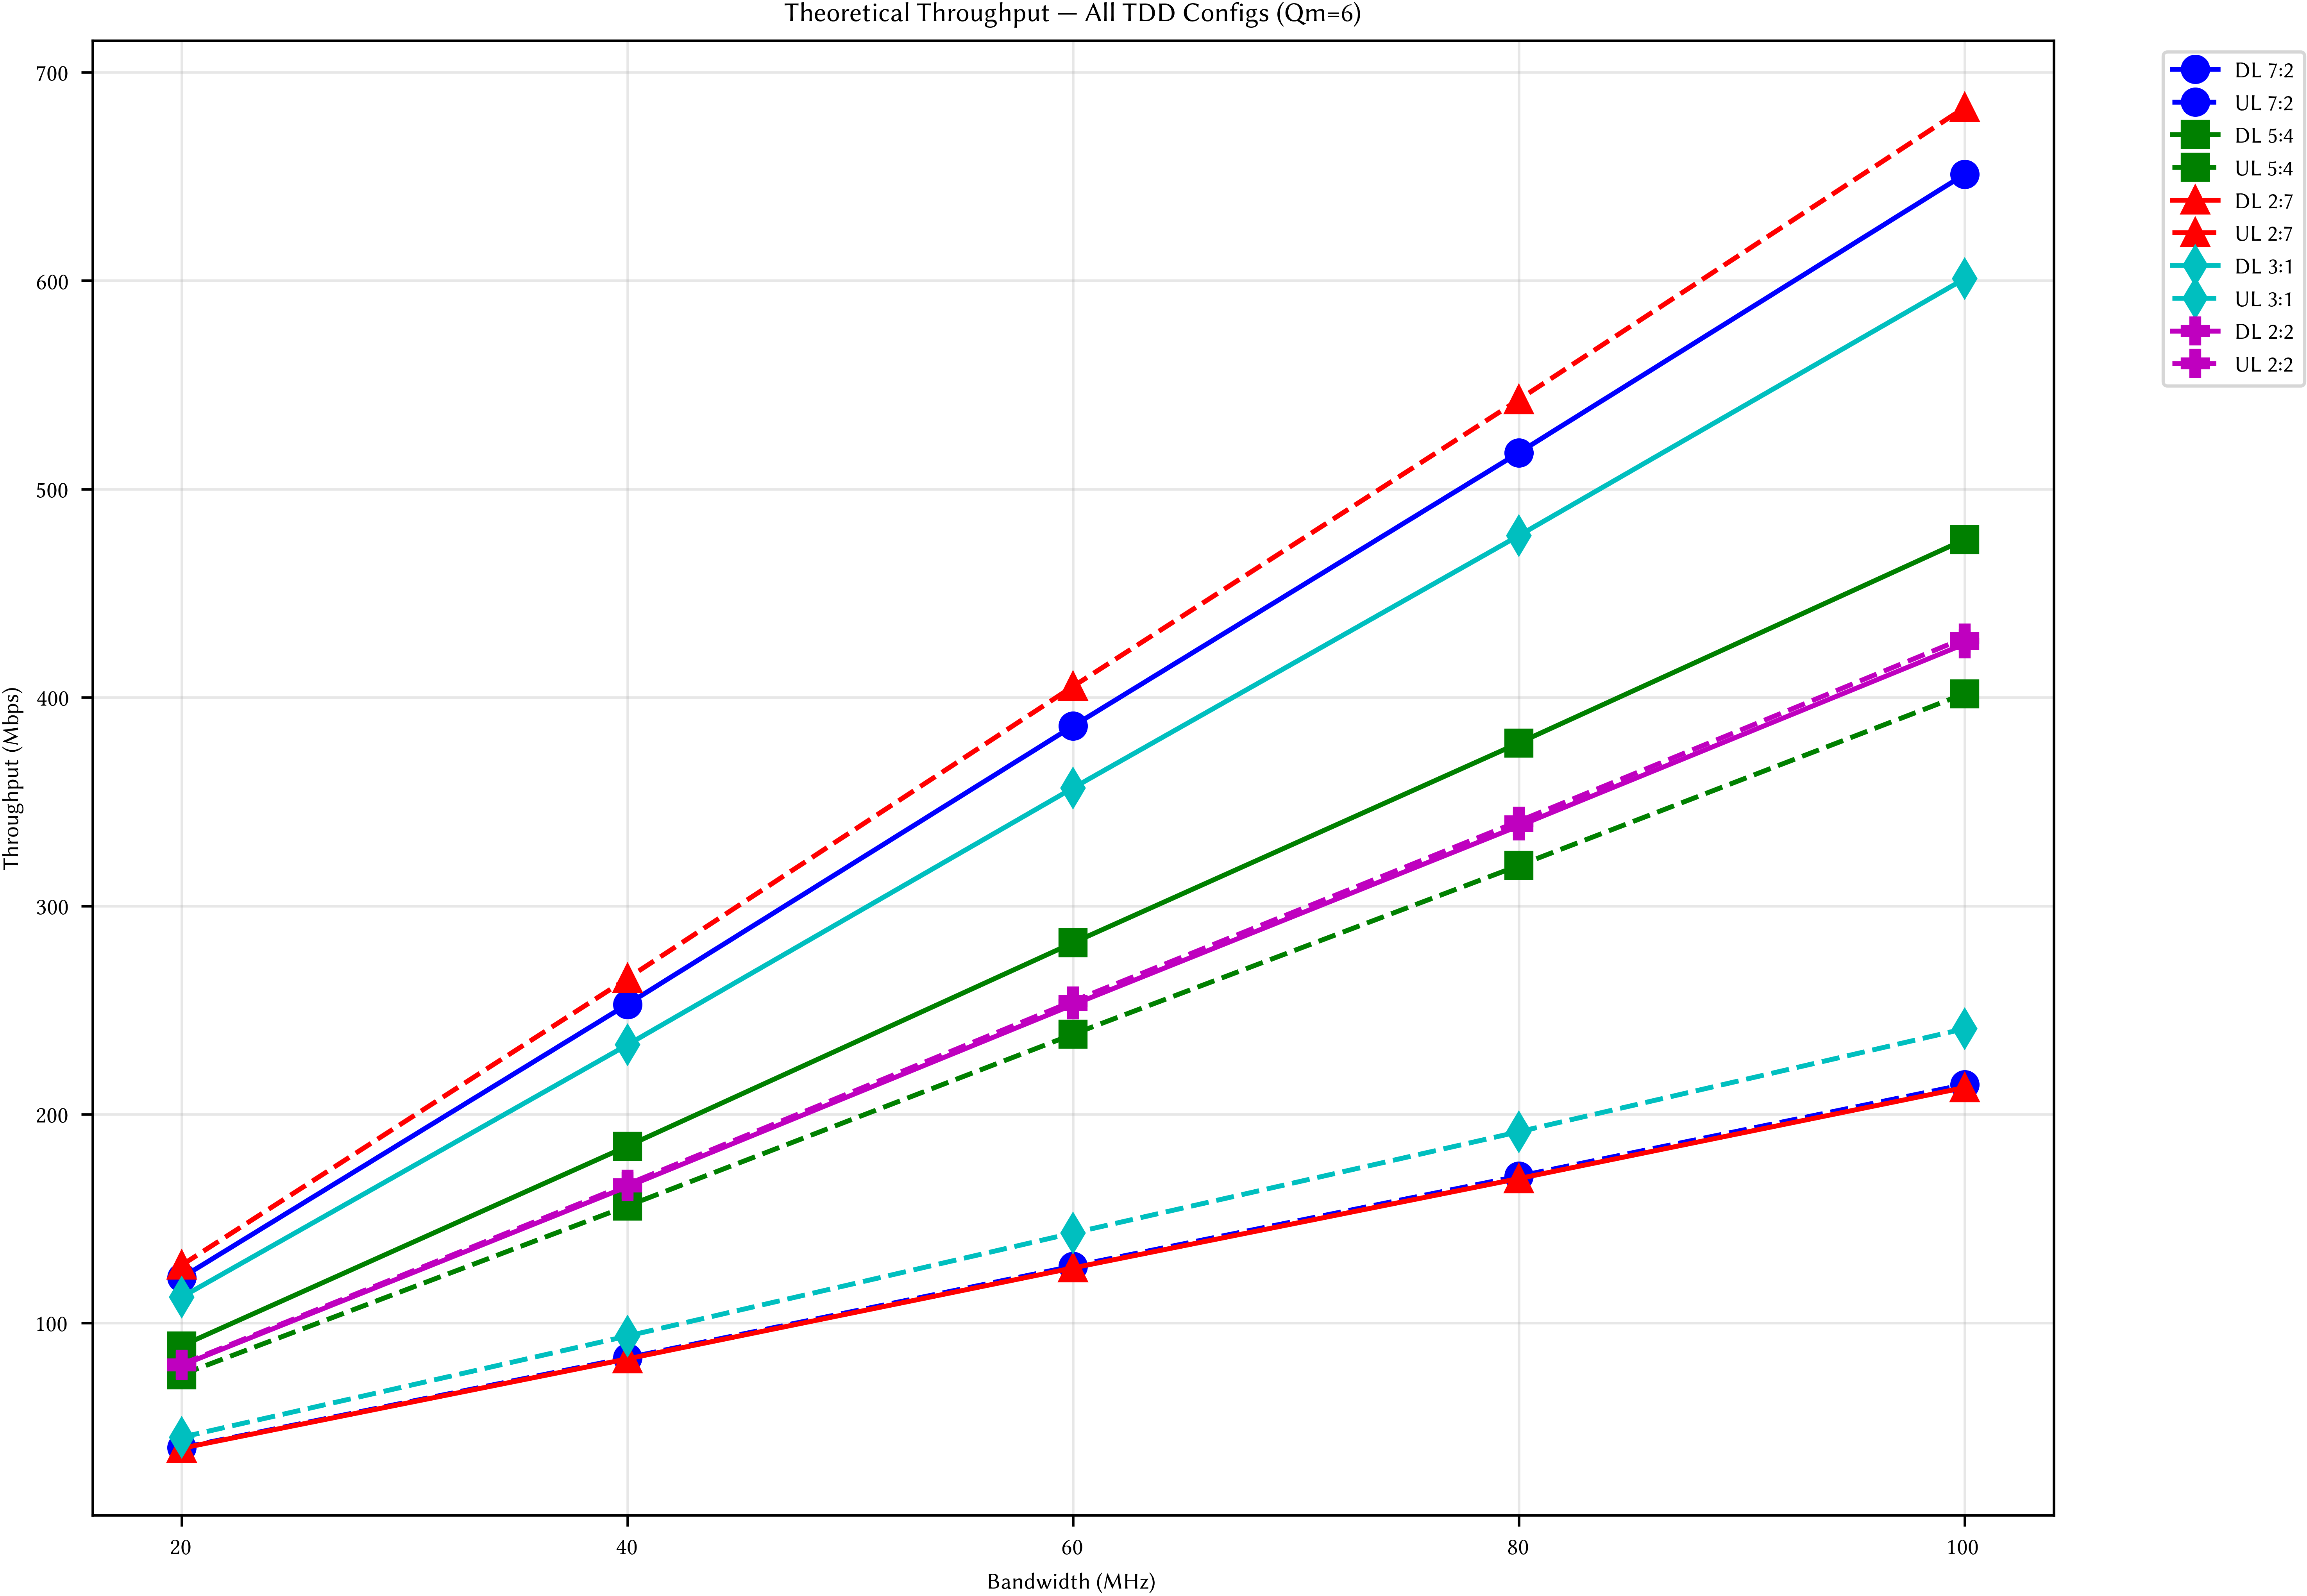

In [27]:
# --- Figure 3: Theoretical only — All TDD configs ---
fig3, ax3 = plt.subplots(figsize=(10, 7))

bw_mhz = [20, 40, 60, 80, 100]
bw_keys = ['20 MHz', '40 MHz', '60 MHz', '80 MHz', '100 MHz']

dl_markers = ['bo-', 'gs-', 'r^-', 'cd-', 'mP-']
ul_markers = ['bo--', 'gs--', 'r^--', 'cd--', 'mP--']

for i, config in enumerate(slot_configs):
    theo_dl = [theoretical_throughput(bw, 6, config, 'dl') for bw in bw_keys]
    theo_ul = [theoretical_throughput(bw, 6, config, 'ul') for bw in bw_keys]

    ax3.plot(bw_mhz, theo_dl, dl_markers[i], markersize=8, label=f'DL {config}')
    ax3.plot(bw_mhz, theo_ul, ul_markers[i], markersize=8, label=f'UL {config}')

ax3.set_xlabel('Bandwidth (MHz)')
ax3.set_ylabel('Throughput (Mbps)')
ax3.set_xticks(bw_mhz)
ax3.set_title('Theoretical Throughput — All TDD Configs (Qm=6)')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_theoretical_all_tdd.pdf', dpi=150)
plt.show()

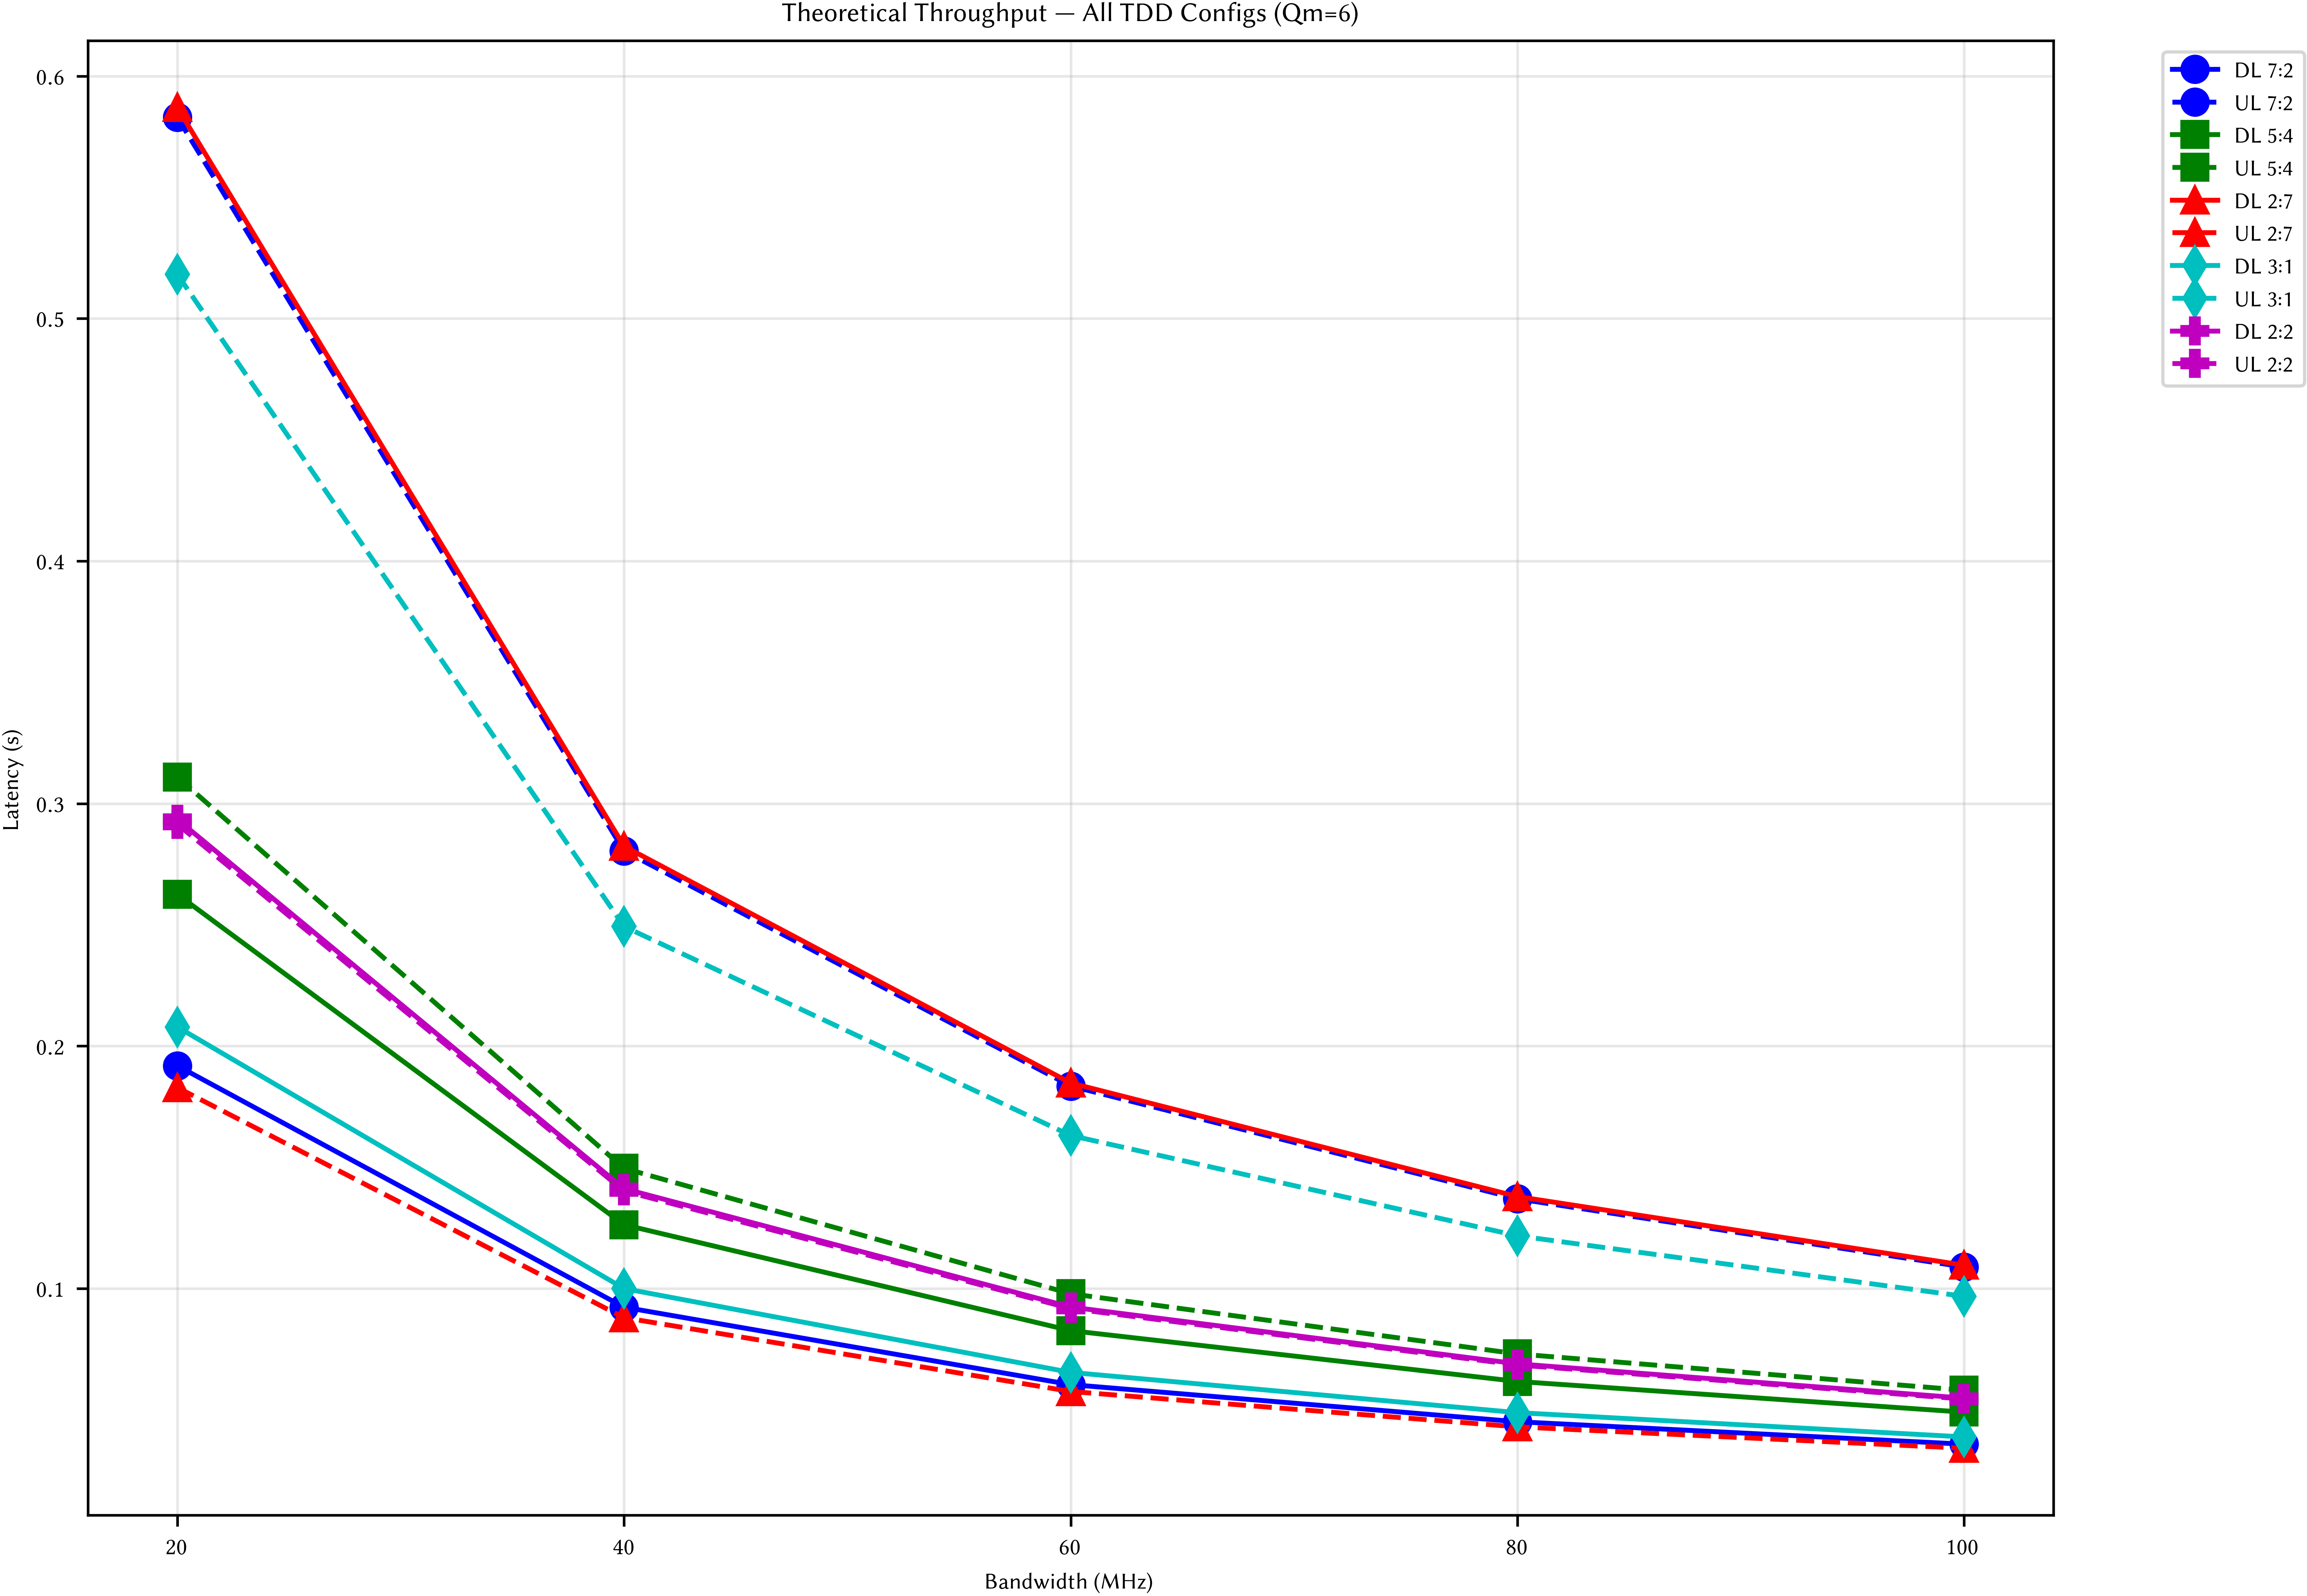

In [41]:
# --- Figure 3: Theoretical only — All TDD configs --- Latency of the model.
fig3, ax3 = plt.subplots(figsize=(10, 7))

bw_mhz = [20, 40, 60, 80, 100]
bw_keys = ['20 MHz', '40 MHz', '60 MHz', '80 MHz', '100 MHz']

dl_markers = ['bo-', 'gs-', 'r^-', 'cd-', 'mP-']
ul_markers = ['bo--', 'gs--', 'r^--', 'cd--', 'mP--']

for i, config in enumerate(slot_configs):
    theo_dl = [data_size / theoretical_throughput(bw, 6, config, 'dl') for bw in bw_keys]
    theo_ul = [data_size / theoretical_throughput(bw, 6, config, 'ul') for bw in bw_keys]

    ax3.plot(bw_mhz, theo_dl, dl_markers[i], markersize=8, label=f'DL {config}')
    ax3.plot(bw_mhz, theo_ul, ul_markers[i], markersize=8, label=f'UL {config}')

ax3.set_xlabel('Bandwidth (MHz)')
ax3.set_ylabel('Latency (s)')
ax3.set_xticks(bw_mhz)
ax3.set_title('Theoretical Throughput — All TDD Configs (Qm=6)')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_theoretical_all_tdd.pdf', dpi=150)
plt.show()

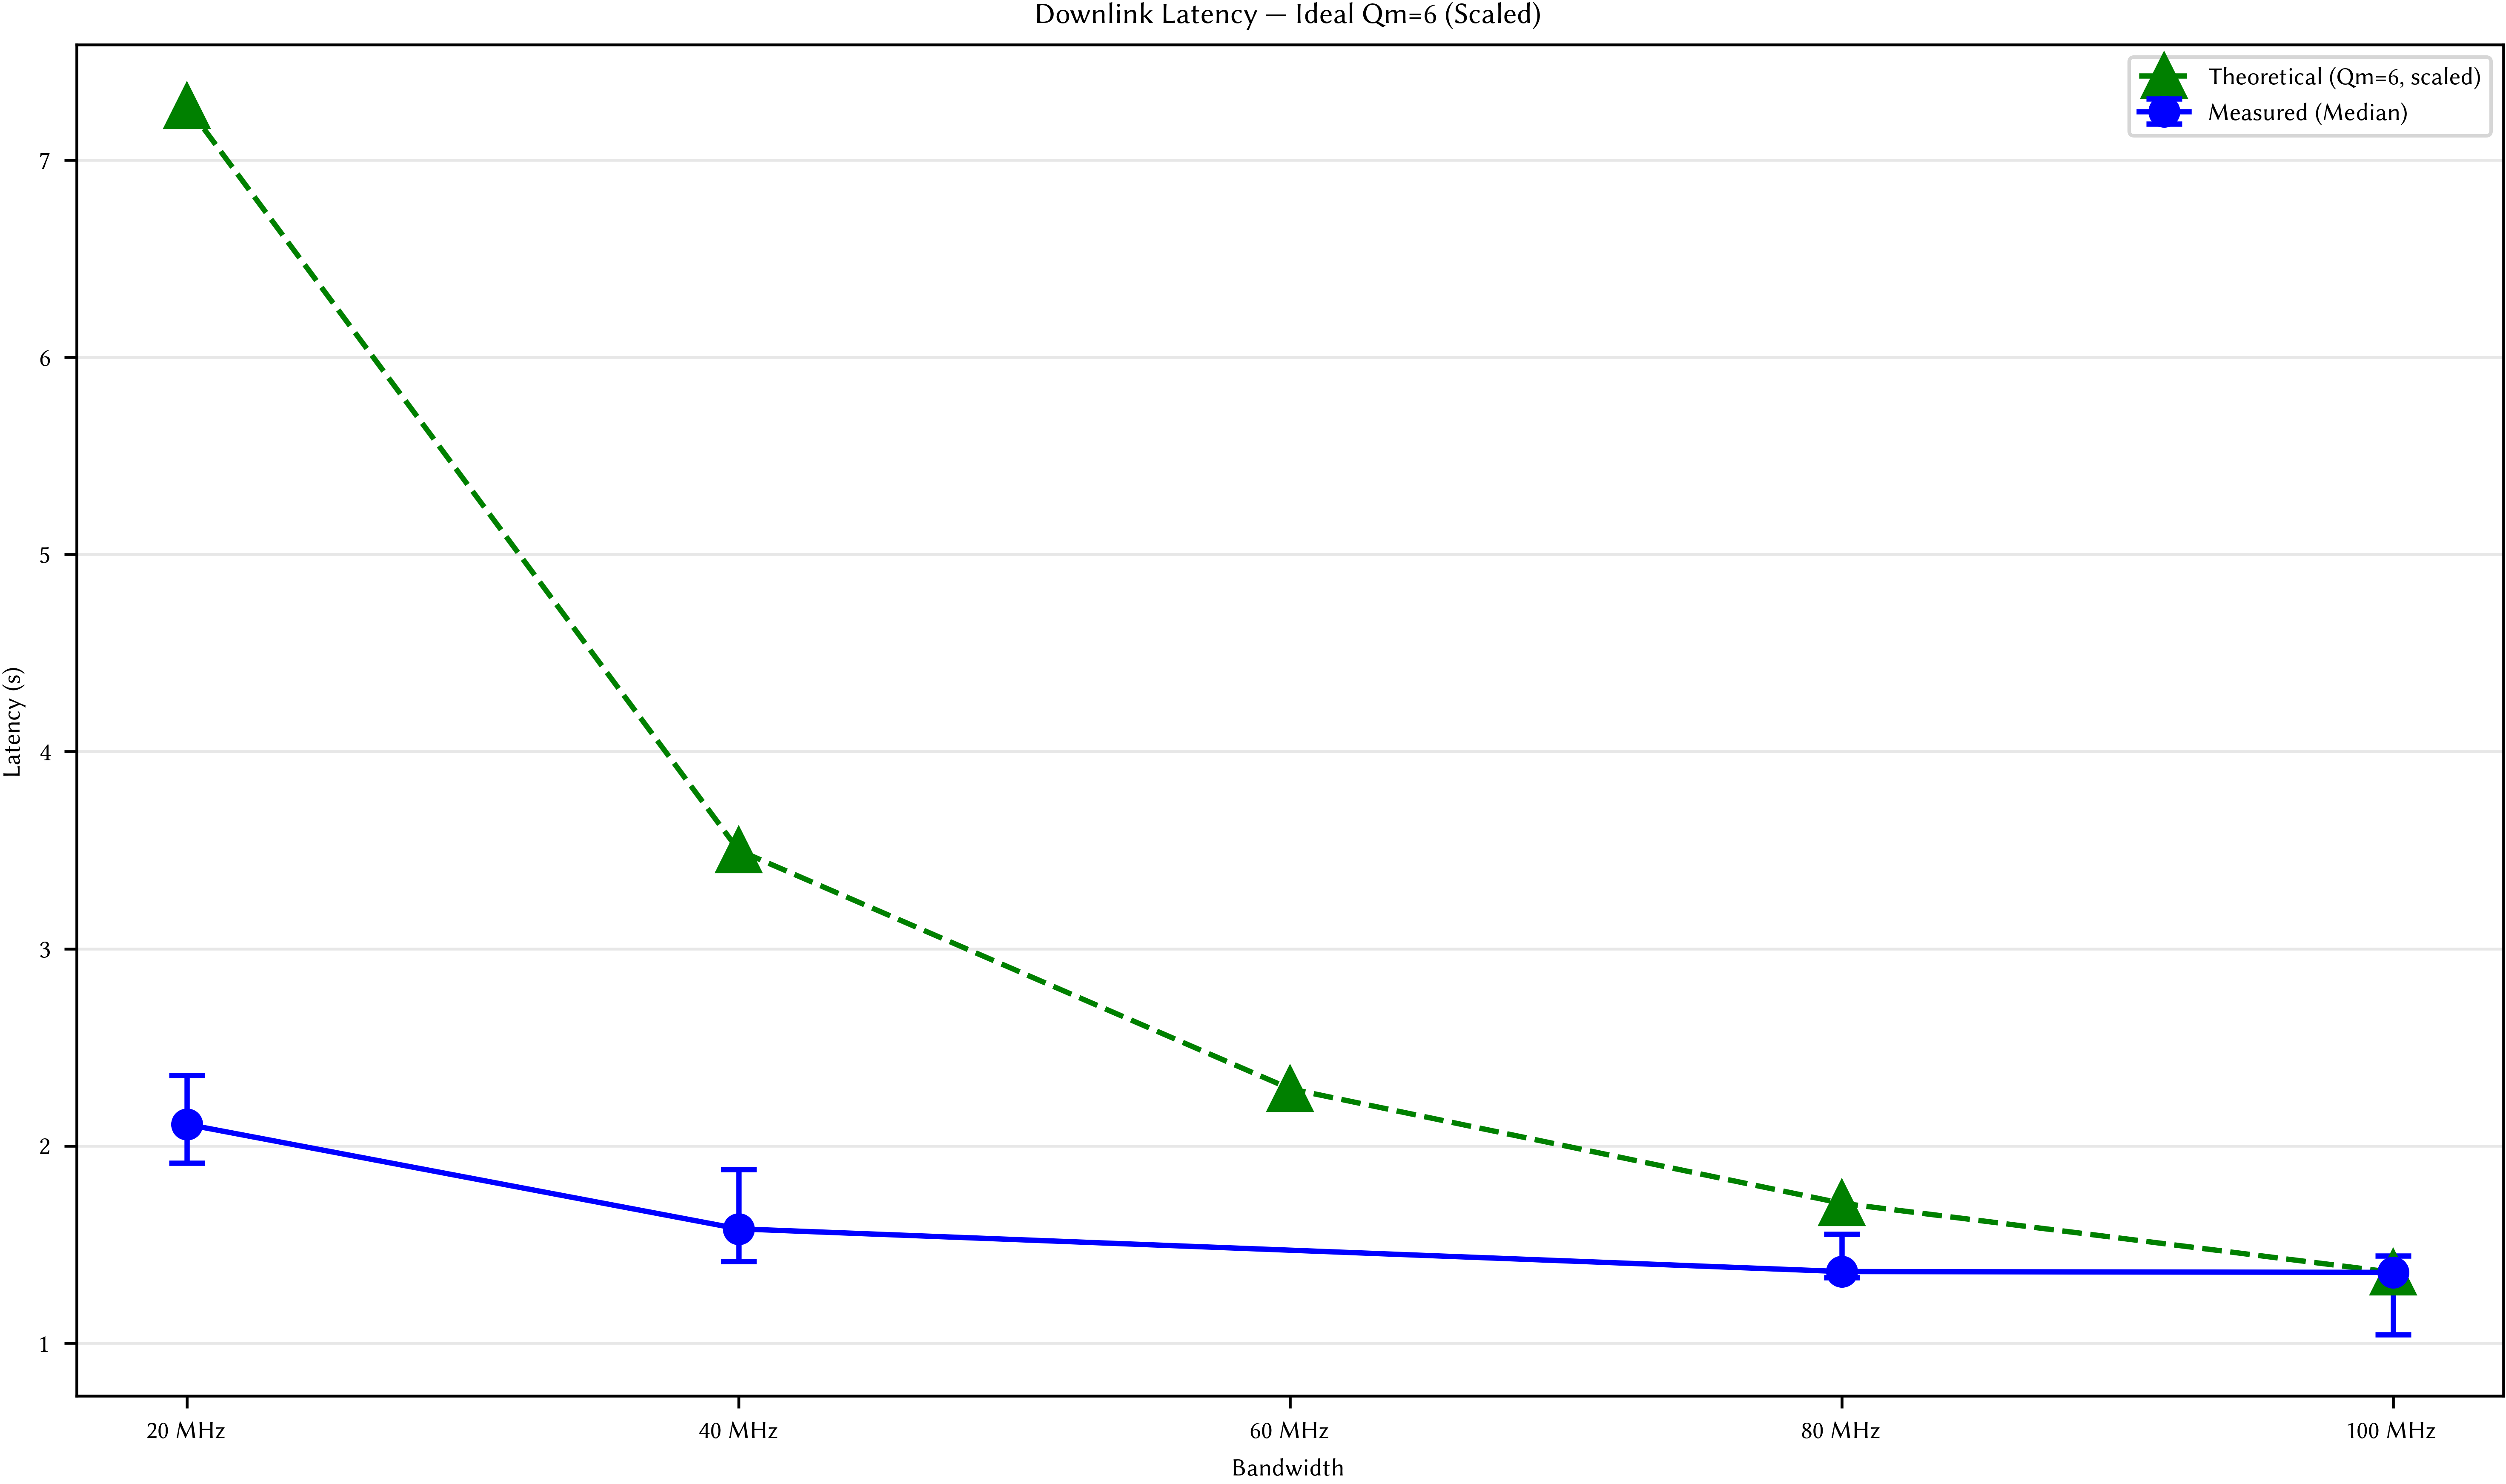

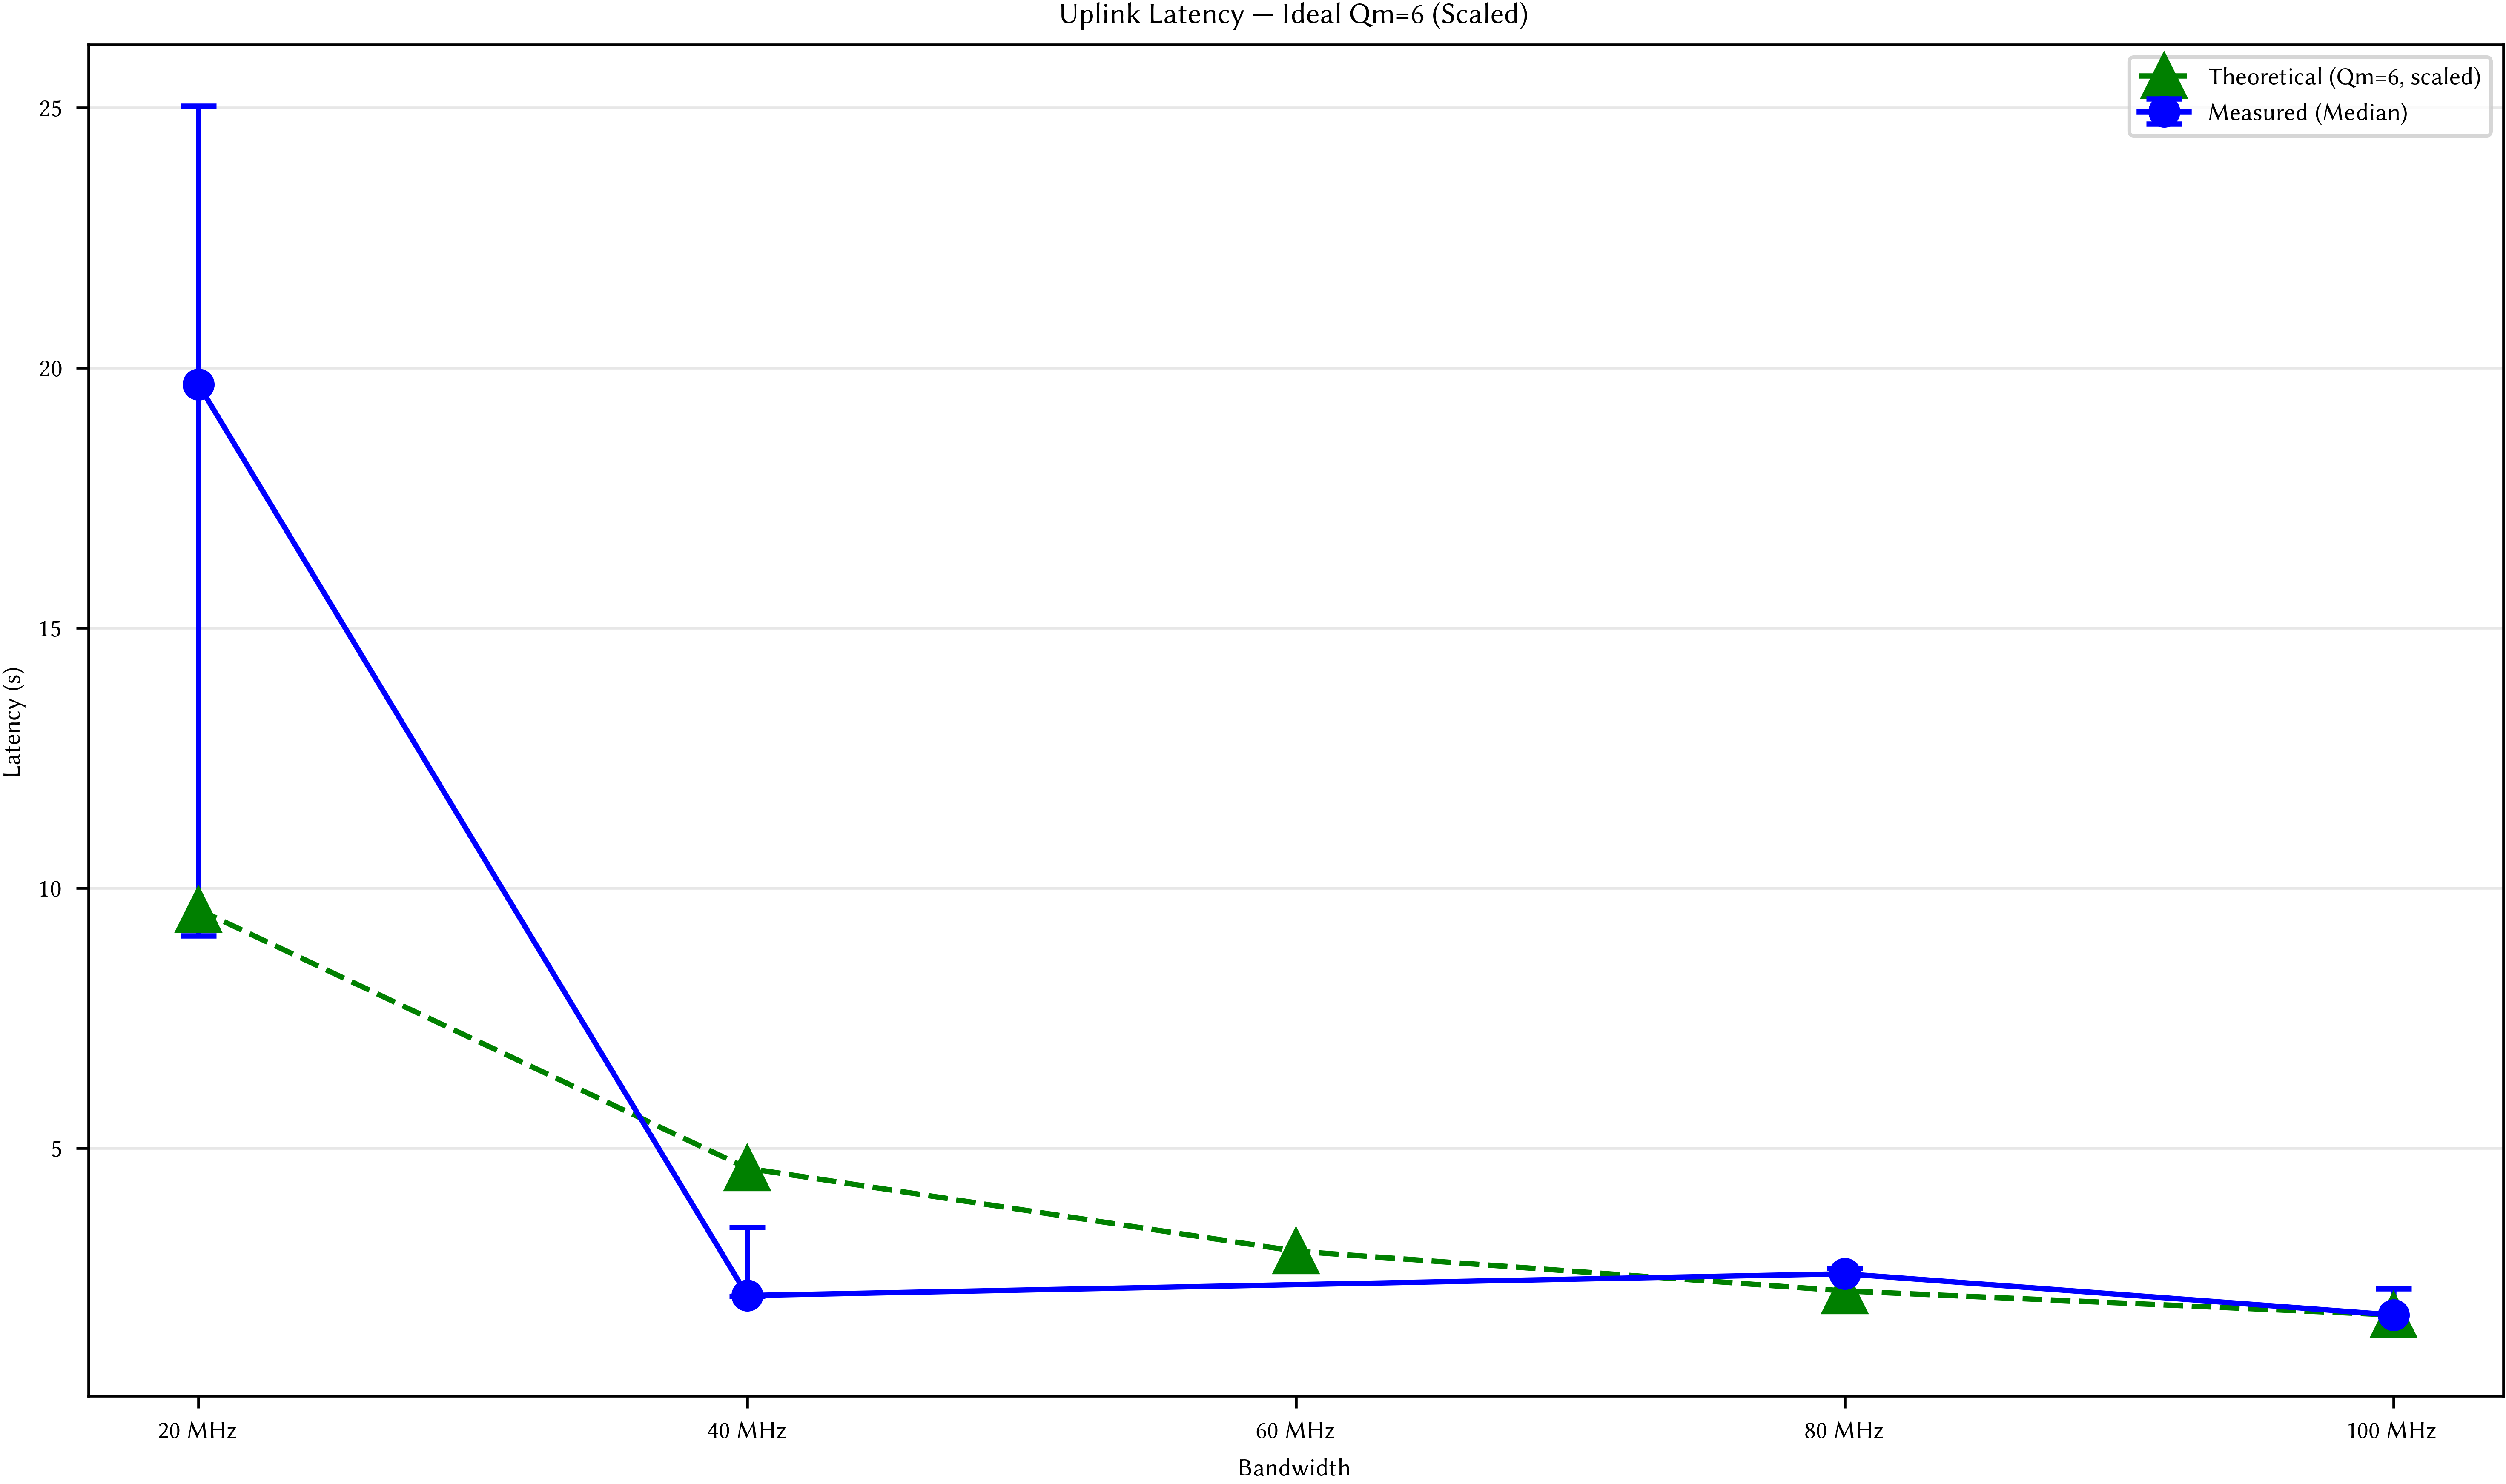

In [44]:
# --- Ideal Qm=6, scaled to experiment — IQR error bars, Latency, separate figures ---
bandwidths_with_60 = ['20 MHz', '40 MHz', '60 MHz', '80 MHz', '100 MHz']
N_PRB['60 MHz'] = 162
data_size = 2.9172 * 8  # megabits

for direction, lat_col, label in zip(
    ['dl', 'ul'], ['downlink_latency', 'uplink_latency'],
    ['Downlink', 'Uplink']
):
    fig, ax = plt.subplots(figsize=(10, 6))

    s100 = df[df['bandwidth'] == '100 MHz']
    theo_100 = data_size / theoretical_throughput('100 MHz', 6, '7:2', direction)
    measured_100 = s100[lat_col].median()
    scale = measured_100 / theo_100

    meas_positions = []
    meas_medians = []
    meas_q1 = []
    meas_q3 = []
    theo_vals = []
    tick_labels = []
    positions = []

    pos = 0
    for bw in bandwidths_with_60:
        subset = df[df['bandwidth'] == bw]
        if not subset.empty:
            vals = subset[lat_col].dropna()
            meas_positions.append(pos)
            meas_medians.append(vals.median())
            meas_q1.append(vals.quantile(0.25))
            meas_q3.append(vals.quantile(0.75))

        theo_vals.append(data_size / theoretical_throughput(bw, 6, '7:2', direction) * scale)
        positions.append(pos)
        tick_labels.append(bw)
        pos += 1

    meas_medians_arr = np.array(meas_medians)
    yerr_lower = meas_medians_arr - np.array(meas_q1)
    yerr_upper = np.array(meas_q3) - meas_medians_arr

    ax.errorbar(meas_positions, meas_medians_arr, yerr=[yerr_lower, yerr_upper],
                fmt='bo-', capsize=5, capthick=1.5, markersize=8,
                label='Measured (Median)')
    ax.plot(positions, theo_vals, 'g^--', markersize=12,
            label='Theoretical (Qm=6, scaled)')

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel('Bandwidth')
    ax.set_ylabel('Latency (s)')
    ax.set_title(f'{label} Latency — Ideal Qm=6 (Scaled)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'latency_ideal_qm_scaled_iqr_{direction}.pdf', dpi=150)
    plt.show()